# 1. Import Libraries

In [3]:
import zipfile
import os
import torch
import random
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


# 2. Function to Initialize Random Seeds

In [4]:
# Function to ensure reproducibility
def initialize_random_seeds(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.cuda.empty_cache()

# Initialize seeds for reproducibility
initialize_random_seeds(42)


# 3. Remove Corrupt Images

In [5]:
from PIL import Image
import os

dataset_directory = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

for directory, _, file_list in os.walk(dataset_directory):
    for filename in file_list:
        file_path = os.path.join(directory, filename)
        try:
            with Image.open(file_path) as image:
                image.verify()  # Verify image integrity
        except (IOError, OSError):
            print(f"Corrupted image found and removed: {file_path}")
            os.remove(file_path)


# 4. Dataset Path and Preprocessing Setup

In [6]:
# Paths to dataset
train_directory = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train'
test_directory = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test'
val_directory = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val'

mean_values = [0.2328, 0.2328, 0.2328]
std_values = [0.0350, 0.0350, 0.0350]

# Image preprocessing transformations
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_values, std=std_values),
])

# Load datasets
train_data = datasets.ImageFolder(train_directory, transform=image_transforms)
test_data = datasets.ImageFolder(test_directory, transform=image_transforms)
val_data = datasets.ImageFolder(val_directory, transform=image_transforms)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)


# 5. Model Setup: EfficientNet

In [7]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

import matplotlib.pyplot as plt

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0 model
efficient_net_model = models.efficientnet_b0(pretrained=True)

# Modify final layer to match our dataset
num_input_features = efficient_net_model.classifier[1].in_features
num_classes = len(train_data.classes)  # Number of classes
efficient_net_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_input_features, num_classes)
)

# Send the model to the device (CPU or GPU)
efficient_net_model = efficient_net_model.to(device)



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# 6. Loss, Optimizer, and Scheduler Setup

In [8]:
# Define the learning rate, weight decay, and other necessary parameters
learning_rate = 0.001
weight_decay = 1e-4
num_epochs = 50
early_stopping_patience = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss function, optimizer, and learning rate scheduler
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(efficient_net_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)


# 7. Training Function

In [9]:
def model_training(model, train_loader, val_loader):
    best_val_loss = float("inf")
    best_train_loss = float("inf")
    best_train_accuracy = 0
    best_val_accuracy = 0

    patience_counter = 0
    best_model_file = "best_bone_fracture_model_effnetb0.pth"

    train_loss_list, val_loss_list = [], []
    train_accuracy_list, val_accuracy_list = [], []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss, correct_predictions, total_samples = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = loss_function(output, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(output, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        average_train_loss = total_train_loss / total_samples
        train_accuracy = correct_predictions / total_samples

        # Validation
        val_loss, val_accuracy = model_evaluation(model, val_loader)

        # Store results
        train_loss_list.append(average_train_loss)
        val_loss_list.append(val_loss)
        train_accuracy_list.append(train_accuracy)
        val_accuracy_list.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {average_train_loss:.4f} | Train Accuracy: {train_accuracy:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")

        scheduler.step(val_loss)

        # Save best model with early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_loss = average_train_loss
            best_train_accuracy = train_accuracy
            best_val_accuracy = val_accuracy
            patience_counter = 0
            torch.save(model.state_dict(), best_model_file)            
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                break

    plot_performance_curves(train_loss_list, val_loss_list, train_accuracy_list, val_accuracy_list)
    return best_val_loss, best_train_loss, best_train_accuracy, best_val_accuracy, best_model_file


# 8. Evaluation Function

In [10]:
def model_evaluation(model, data_loader):
    model.eval()
    loss, correct_predictions, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            loss += loss_function(output, labels).item() * images.size(0)
            _, predicted = torch.max(output, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    average_loss = loss / total_samples
    accuracy = correct_predictions / total_samples
    return average_loss, accuracy


# 9. Plotting Training Curves

In [11]:
# -------------------- PERFORMANCE CURVES --------------------
def plot_performance_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    # Loss graph
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss During Training & Validation")
    plt.legend()

    # Accuracy graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Training Accuracy")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy During Training & Validation")
    plt.legend()

    plt.show()

# 10. Final Model Evaluation and Test

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/50] | Train Loss: 0.5956 | Train Accuracy: 0.6883 | Val Loss: 0.4447 | Val Accuracy: 0.8565
Epoch [2/50] | Train Loss: 0.3926 | Train Accuracy: 0.8621 | Val Loss: 0.2958 | Val Accuracy: 0.8963
Epoch [3/50] | Train Loss: 0.2463 | Train Accuracy: 0.9243 | Val Loss: 0.2244 | Val Accuracy: 0.9216
Epoch [4/50] | Train Loss: 0.1546 | Train Accuracy: 0.9584 | Val Loss: 0.1547 | Val Accuracy: 0.9469
Epoch [5/50] | Train Loss: 0.1013 | Train Accuracy: 0.9757 | Val Loss: 0.1321 | Val Accuracy: 0.9650
Epoch [6/50] | Train Loss: 0.0722 | Train Accuracy: 0.9824 | Val Loss: 0.1023 | Val Accuracy: 0.9674
Epoch [7/50] | Train Loss: 0.0546 | Train Accuracy: 0.9873 | Val Loss: 0.0911 | Val Accuracy: 0.9747
Epoch [8/50] | Train Loss: 0.0435 | Train Accuracy: 0.9900 | Val Loss: 0.0801 | Val Accuracy: 0.9735
Epoch [9/50] | Train Loss: 0.0361 | Train Accuracy: 0.9913 | Val Loss: 0.0685 | Val Accuracy: 0.9759
Epoch [10/50] | Train Loss: 0.0301 | Train Accuracy: 0.9929 | Val Loss: 0.0608 | Val Accura

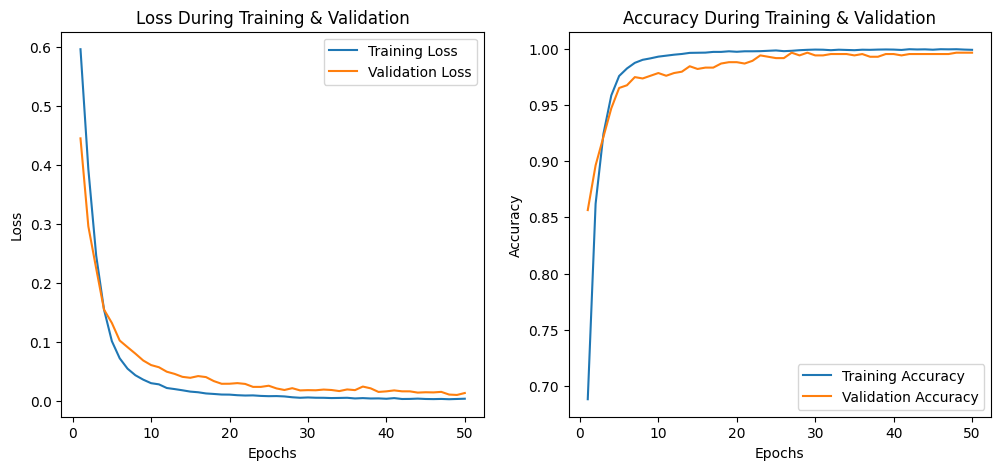



Details of Best Model (Saved at: 'best_bone_fracture_model_effnetb0.pth')

Training Loss: 0.0034 | Training Accuracy: 0.9991
Validation Loss: 0.0102 | Validation Accuracy: 0.9964


In [12]:
# -------------------- FINAL EVALUATION --------------------
best_val_loss, best_train_loss, best_train_acc, best_val_acc, best_model_path = model_training(efficient_net_model, train_loader, val_loader)
print(f"\n\nDetails of Best Model (Saved at: '{best_model_path}')\n")
print(f"Training Loss: {best_train_loss:.4f} | Training Accuracy: {best_train_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f} | Validation Accuracy: {best_val_acc:.4f}")



In [13]:
def evaluate_with_metrics(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    total_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    # Calculate precision, recall, and F1-score
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, cm


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


<ipython-input-15-0384ba12a664>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  efficient_net_model.load_state_dict(torch.load("best_bone_fracture_model_effnetb0.pth"))



Test Results: 

Test Loss: 0.0579
Test Accuracy: 0.9901
Precision: 0.9902
Recall: 0.9901
F1 Score: 0.9901


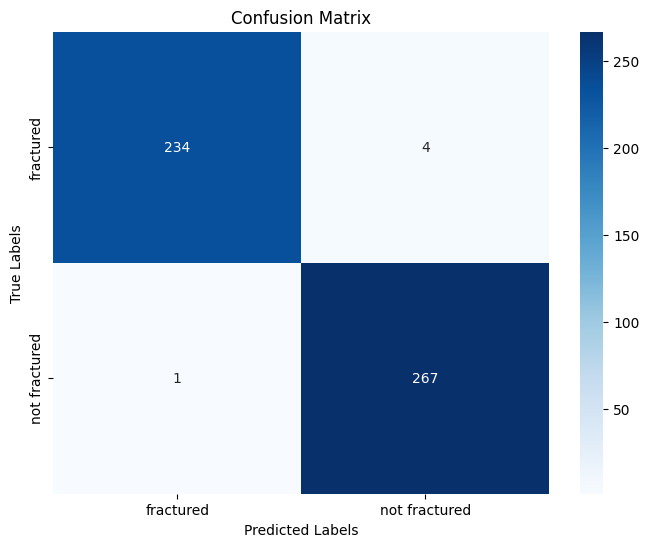

In [15]:
# -------------------- LOAD BEST MODEL & TEST --------------------
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

efficient_net_model.load_state_dict(torch.load("best_bone_fracture_model_effnetb0.pth"))

test_loss, test_acc, precision, recall, f1, cm_result  = evaluate_with_metrics(efficient_net_model, test_loader)

print(f"\nTest Results: \n")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Class names for confusion matrix
class_labels = train_loader.dataset.classes

# Plot confusion matrix
plot_confusion_matrix(cm_result , class_labels)


In [16]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load ResNet50 model pretrained on ImageNet
resnet50_model = models.resnet50(pretrained=True)

# Modify the final fully connected layer to match the number of classes in your dataset
num_features_resnet = resnet50_model.fc.in_features
resnet50_model.fc = nn.Sequential(
    nn.Dropout(0.5),  # Dropout for regularization
    nn.Linear(num_features_resnet, num_classes)  # Adjust output layer to match the number of classes
)

# Move model to the appropriate device (GPU/CPU)
resnet50_model = resnet50_model.to(device)

# Loss function, optimizer, and learning rate scheduler
loss_function_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.SGD(resnet50_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=5)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/50] | Train Loss: 0.7355 | Train Accuracy: 0.4792 | Val Loss: 0.7274 | Val Accuracy: 0.4065
Epoch [2/50] | Train Loss: 0.7309 | Train Accuracy: 0.4882 | Val Loss: 0.7283 | Val Accuracy: 0.4053
Epoch [3/50] | Train Loss: 0.7357 | Train Accuracy: 0.4813 | Val Loss: 0.7273 | Val Accuracy: 0.4089
Epoch [4/50] | Train Loss: 0.7363 | Train Accuracy: 0.4843 | Val Loss: 0.7271 | Val Accuracy: 0.4041
Epoch [5/50] | Train Loss: 0.7314 | Train Accuracy: 0.4830 | Val Loss: 0.7275 | Val Accuracy: 0.4089
Epoch [6/50] | Train Loss: 0.7360 | Train Accuracy: 0.4803 | Val Loss: 0.7278 | Val Accuracy: 0.4077
Epoch [7/50] | Train Loss: 0.7341 | Train Accuracy: 0.4830 | Val Loss: 0.7268 | Val Accuracy: 0.4041
Epoch [8/50] | Train Loss: 0.7370 | Train Accuracy: 0.4791 | Val Loss: 0.7274 | Val Accuracy: 0.4113
Epoch [9/50] | Train Loss: 0.7327 | Train Accuracy: 0.4798 | Val Loss: 0.7268 | Val Accuracy: 0.4029
Epoch [10/50] | Train Loss: 0.7326 | Train Accuracy: 0.4845 | Val Loss: 0.7282 | Val Accura

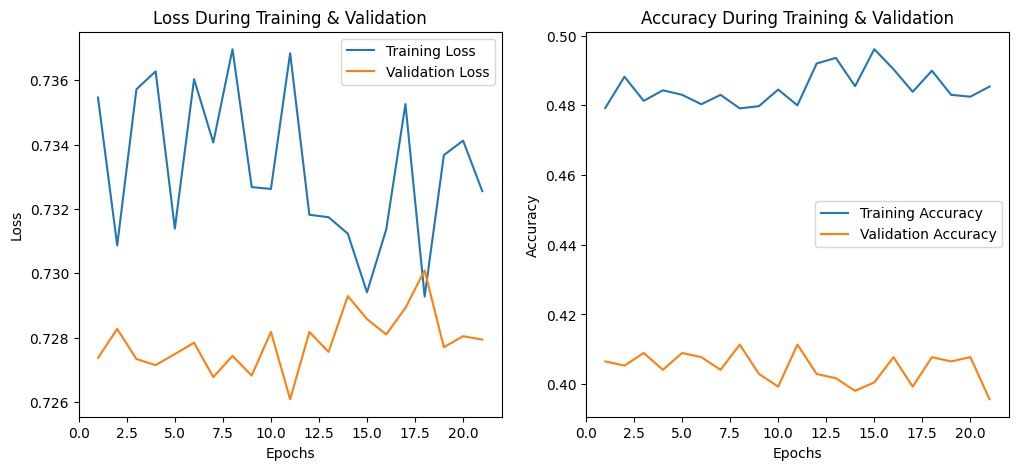

In [17]:
best_val_loss_resnet, best_train_loss_resnet, best_train_acc_resnet, best_val_acc_resnet, best_model_path_resnet = model_training(resnet50_model, train_loader, val_loader)


In [18]:
resnet50_model.load_state_dict(torch.load(best_model_path_resnet), strict=False)
test_loss_resnet, test_acc_resnet, precision_resnet, recall_resnet, f1_resnet, cm_resnet = evaluate_with_metrics(resnet50_model, test_loader)


<ipython-input-18-eb7bc5198784>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50_model.load_state_dict(torch.load(best_model_path_resnet), strict=False)


In [19]:
# Load VGG16 model pretrained on ImageNet
vgg16_model = models.vgg16(pretrained=True)

# Modify the final fully connected layers to match the number of classes
num_features_vgg16 = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),  # Dropout for regularization
    nn.Linear(num_features_vgg16, num_classes)  # Adjust output layer to match the number of classes
)

# Move model to the appropriate device (GPU/CPU)
vgg16_model = vgg16_model.to(device)

# Loss function, optimizer, and learning rate scheduler
loss_function_vgg16 = nn.CrossEntropyLoss()
optimizer_vgg16 = optim.SGD(vgg16_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
scheduler_vgg16 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_vgg16, mode='min', factor=0.1, patience=5)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/50] | Train Loss: 1.0278 | Train Accuracy: 0.4891 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [2/50] | Train Loss: 1.0020 | Train Accuracy: 0.4992 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [3/50] | Train Loss: 1.0125 | Train Accuracy: 0.5001 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [4/50] | Train Loss: 1.0080 | Train Accuracy: 0.4984 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [5/50] | Train Loss: 1.0307 | Train Accuracy: 0.4985 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [6/50] | Train Loss: 1.0371 | Train Accuracy: 0.4926 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [7/50] | Train Loss: 1.0077 | Train Accuracy: 0.5041 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [8/50] | Train Loss: 1.0401 | Train Accuracy: 0.4908 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [9/50] | Train Loss: 1.0271 | Train Accuracy: 0.4991 | Val Loss: 0.8445 | Val Accuracy: 0.3860
Epoch [10/50] | Train Loss: 1.0308 | Train Accuracy: 0.4968 | Val Loss: 0.8445 | Val Accura

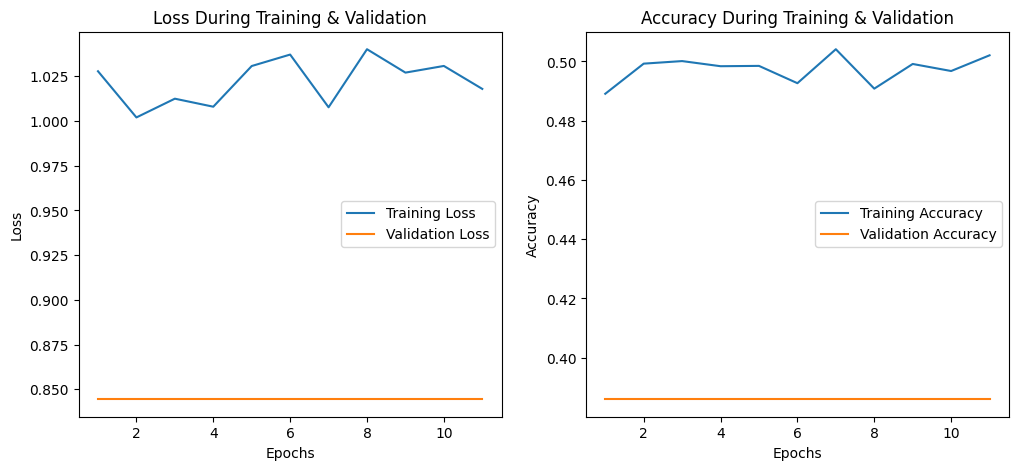

In [20]:
best_val_loss_vgg16, best_train_loss_vgg16, best_train_acc_vgg16, best_val_acc_vgg16, best_model_path_vgg16 = model_training(vgg16_model, train_loader, val_loader)


In [21]:
vgg16_model.load_state_dict(torch.load(best_model_path_vgg16))
test_loss_vgg16, test_acc_vgg16, precision_vgg16, recall_vgg16, f1_vgg16, cm_vgg16 = evaluate_with_metrics(vgg16_model, test_loader)


<ipython-input-21-7094b5cb253a>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vgg16_model.load_state_dict(torch.load(best_model_path_vgg16))


In [22]:
# Compare the models' performance on the test set
print(f"ResNet50 Test Accuracy: {test_acc_resnet:.4f} | Precision: {precision_resnet:.4f} | Recall: {recall_resnet:.4f} | F1: {f1_resnet:.4f}")
print(f"VGG16 Test Accuracy: {test_acc_vgg16:.4f} | Precision: {precision_vgg16:.4f} | Recall: {recall_vgg16:.4f} | F1: {f1_vgg16:.4f}")
print(f"EfficientNet Test Accuracy: {test_acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


ResNet50 Test Accuracy: 0.4506 | Precision: 0.4555 | Recall: 0.4506 | F1: 0.4237
VGG16 Test Accuracy: 0.4822 | Precision: 0.5032 | Recall: 0.4822 | F1: 0.4271
EfficientNet Test Accuracy: 0.9901 | Precision: 0.9902 | Recall: 0.9901 | F1: 0.9901


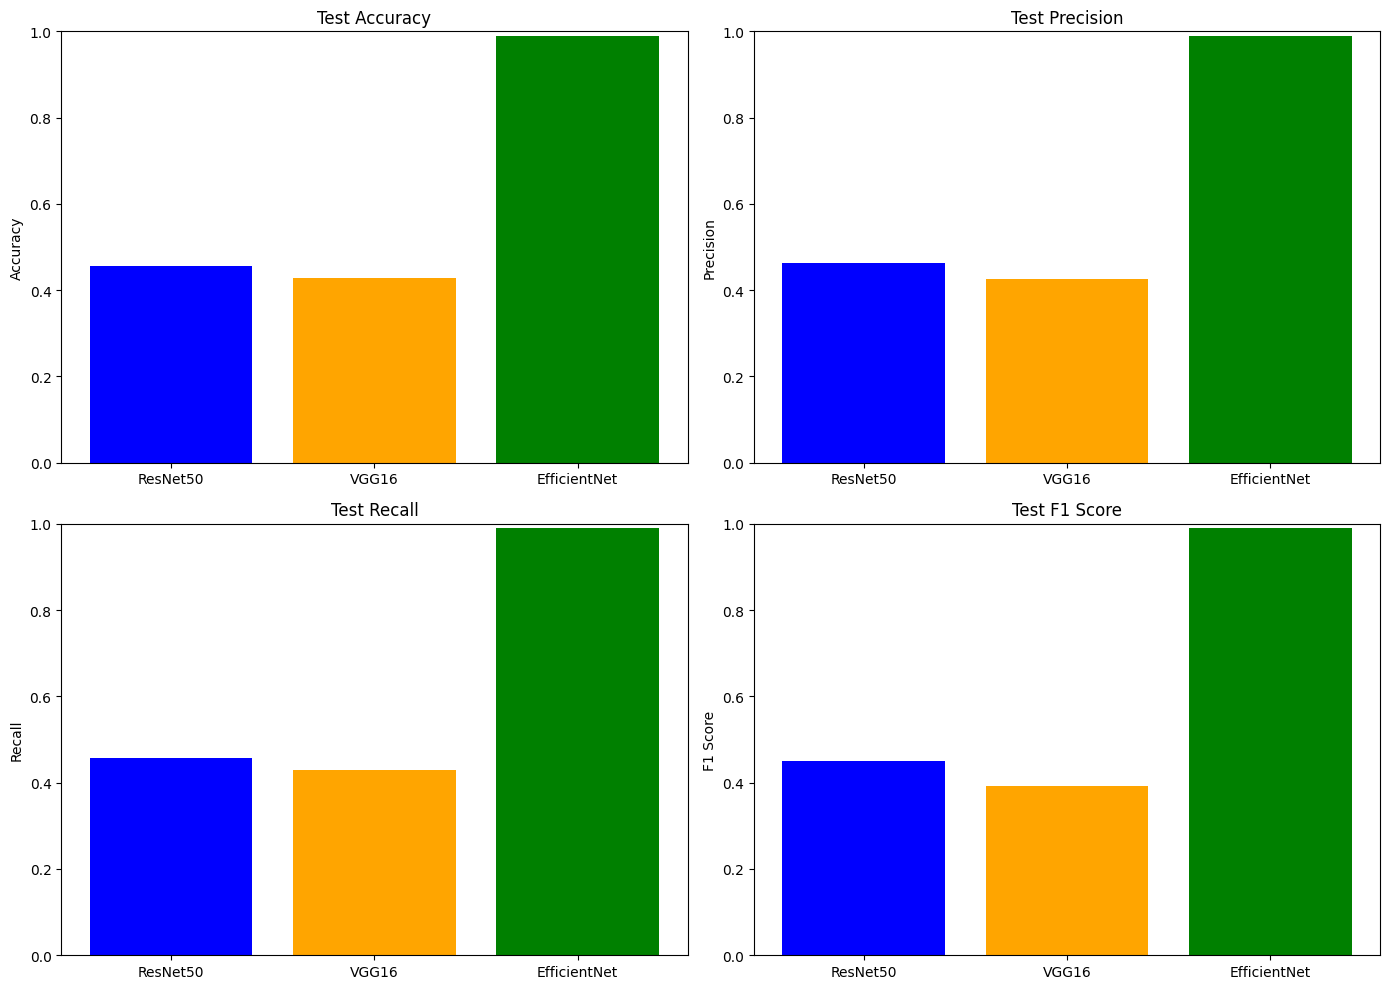

In [23]:
import matplotlib.pyplot as plt

# Results from models
models = ['ResNet50', 'VGG16', 'EfficientNet']
accuracy = [0.4565, 0.4289, 0.9901]
precision = [0.4626, 0.4251, 0.9902]
recall = [0.4565, 0.4289, 0.9901]
f1 = [0.4493, 0.3934, 0.9901]

# Plotting the comparison graph
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy plot
axes[0, 0].bar(models, accuracy, color=['blue', 'orange', 'green'])
axes[0, 0].set_title('Test Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_ylabel('Accuracy')

# Precision plot
axes[0, 1].bar(models, precision, color=['blue', 'orange', 'green'])
axes[0, 1].set_title('Test Precision')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_ylabel('Precision')

# Recall plot
axes[1, 0].bar(models, recall, color=['blue', 'orange', 'green'])
axes[1, 0].set_title('Test Recall')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel('Recall')

# F1 Score plot
axes[1, 1].bar(models, f1, color=['blue', 'orange', 'green'])
axes[1, 1].set_title('Test F1 Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel('F1 Score')

plt.tight_layout()
plt.show()


In [1]:
# Import required libraries
import os
import cv2
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage import filters



In [2]:
# 1. Image Preprocessing: Feature Extraction (Edge Detection and Texture Analysis)

# Function to extract features from X-ray images
def extract_features(image_path):
    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Check if the image was loaded correctly
    if image is None:
        print(f"Warning: {image_path} is corrupt or unreadable, skipping...")
        return None
    
    # Resize image to fixed size (224x224)
    image = cv2.resize(image, (224, 224))
    
    # Edge detection using Sobel filter (for feature extraction)
    edges = filters.sobel(image)
    
    # Texture Analysis using Gray Level Co-occurrence Matrix (GLCM)
    glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)
    
    # Extract contrast, correlation, energy, and homogeneity as texture features
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    
    # Combine edge detection and texture features into a single feature vector
    features = np.concatenate([edges.flatten(), [contrast, correlation, energy, homogeneity]])
    
    return features



In [3]:
# 2. Load Dataset and Extract Features

# Paths to your dataset folders
train_dir = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train'
test_dir = '/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test'

# Initialize lists to store features and labels
X = []
y = []

# Assuming that the directories are organized by class (e.g., "fracture" and "not fractured")
for class_label in os.listdir(train_dir):
    class_folder = os.path.join(train_dir, class_label)
    if os.path.isdir(class_folder):
        for image_name in os.listdir(class_folder):
            image_path = os.path.join(class_folder, image_name)
            if image_path.endswith('.png') or image_path.endswith('.jpg'):
                # Extract features from image and append to the list
                features = extract_features(image_path)
                if features is not None:
                    X.append(features)
                    y.append(0 if class_label == 'not fractured' else 1)  # Label: 0 = non-fracture, 1 = fracture

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)



In [4]:
# 3. Data Splitting and Standardization

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [5]:
# 4. Support Vector Machine (SVM) Implementation

# Initialize the SVM model
svm_model = svm.SVC(kernel='rbf', C=1, gamma='scale')

# Train the SVM model
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f}")
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))



SVM Accuracy: 0.9881
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       918
           1       0.99      0.98      0.99       925

    accuracy                           0.99      1843
   macro avg       0.99      0.99      0.99      1843
weighted avg       0.99      0.99      0.99      1843



In [6]:
# 5. Random Forest (RF) Implementation

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))




Random Forest Accuracy: 0.9919
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       918
           1       0.99      0.99      0.99       925

    accuracy                           0.99      1843
   macro avg       0.99      0.99      0.99      1843
weighted avg       0.99      0.99      0.99      1843



In [7]:
# 6. Dimensionality Reduction: Apply PCA

# Apply PCA to reduce the dimensionality
pca = PCA(n_components=0.95)  # Retain 95% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Check the reduced shape
print("Original shape:", X_train.shape)
print("Reduced shape after PCA:", X_train_pca.shape)

# Train the SVM model on PCA-transformed data
svm_model.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred_svm_pca = svm_model.predict(X_test_pca)

# Evaluate the SVM model
accuracy_svm_pca = accuracy_score(y_test, y_pred_svm_pca)
print(f"SVM Accuracy after PCA: {accuracy_svm_pca:.4f}")
print("SVM Classification Report after PCA:")
print(classification_report(y_test, y_pred_svm_pca))

# Train the Random Forest model on PCA-transformed data
rf_model.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred_rf_pca = rf_model.predict(X_test_pca)

# Evaluate the Random Forest model
accuracy_rf_pca = accuracy_score(y_test, y_pred_rf_pca)
print(f"Random Forest Accuracy after PCA: {accuracy_rf_pca:.4f}")
print("Random Forest Classification Report after PCA:")
print(classification_report(y_test, y_pred_rf_pca))




Original shape: (7372, 50180)
Reduced shape after PCA: (7372, 1796)
SVM Accuracy after PCA: 0.9821
SVM Classification Report after PCA:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       918
           1       0.99      0.97      0.98       925

    accuracy                           0.98      1843
   macro avg       0.98      0.98      0.98      1843
weighted avg       0.98      0.98      0.98      1843

Random Forest Accuracy after PCA: 0.9788
Random Forest Classification Report after PCA:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       918
           1       0.99      0.96      0.98       925

    accuracy                           0.98      1843
   macro avg       0.98      0.98      0.98      1843
weighted avg       0.98      0.98      0.98      1843



In [8]:
# 7. Dimensionality Reduction: Apply LDA

# Apply LDA to reduce dimensionality
lda = LinearDiscriminantAnalysis(n_components=1)  # You can adjust the number of components
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Check the reduced shape
print("Original shape:", X_train.shape)
print("Reduced shape after LDA:", X_train_lda.shape)

# Train the SVM model on LDA-transformed data
svm_model.fit(X_train_lda, y_train)

# Make predictions on the test set
y_pred_svm_lda = svm_model.predict(X_test_lda)

# Evaluate the SVM model
accuracy_svm_lda = accuracy_score(y_test, y_pred_svm_lda)
print(f"SVM Accuracy after LDA: {accuracy_svm_lda:.4f}")
print("SVM Classification Report after LDA:")
print(classification_report(y_test, y_pred_svm_lda))

# Train the Random Forest model on LDA-transformed data
rf_model.fit(X_train_lda, y_train)

# Make predictions on the test set
y_pred_rf_lda = rf_model.predict(X_test_lda)

# Evaluate the Random Forest model
accuracy_rf_lda = accuracy_score(y_test, y_pred_rf_lda)
print(f"Random Forest Accuracy after LDA: {accuracy_rf_lda:.4f}")
print("Random Forest Classification Report after LDA:")
print(classification_report(y_test, y_pred_rf_lda))




Original shape: (7372, 50180)
Reduced shape after LDA: (7372, 1)
SVM Accuracy after LDA: 0.9533
SVM Classification Report after LDA:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       918
           1       0.97      0.94      0.95       925

    accuracy                           0.95      1843
   macro avg       0.95      0.95      0.95      1843
weighted avg       0.95      0.95      0.95      1843

Random Forest Accuracy after LDA: 0.9555
Random Forest Classification Report after LDA:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       918
           1       0.97      0.94      0.96       925

    accuracy                           0.96      1843
   macro avg       0.96      0.96      0.96      1843
weighted avg       0.96      0.96      0.96      1843



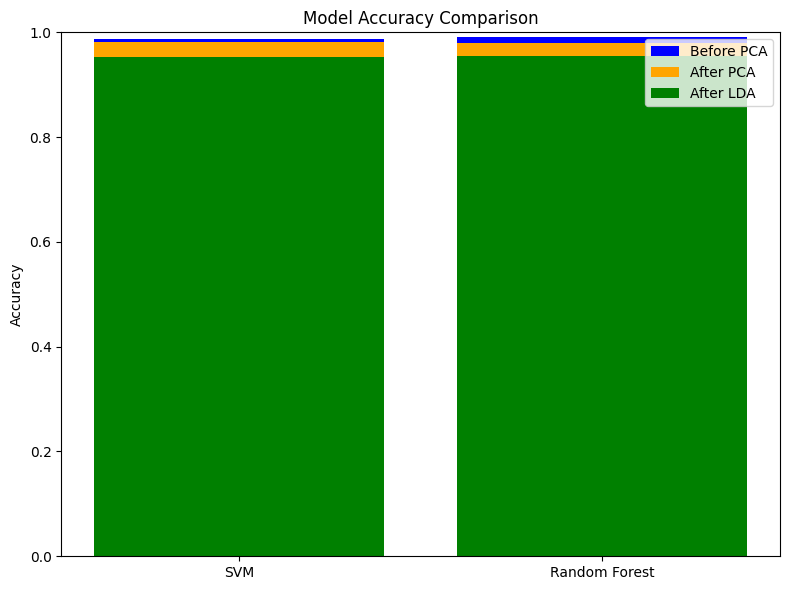

In [9]:
# 8. Visualization of Results

# Plotting the comparison graph
models = ['SVM', 'Random Forest']
accuracy_before_pca = [accuracy_svm, accuracy_rf]
accuracy_after_pca = [accuracy_svm_pca, accuracy_rf_pca]
accuracy_after_lda = [accuracy_svm_lda, accuracy_rf_lda]

fig, axes = plt.subplots(figsize=(8, 6))

# Plot accuracy before and after PCA/ LDA
axes.bar(models, accuracy_before_pca, color='blue', label='Before PCA')
axes.bar(models, accuracy_after_pca, color='orange', label='After PCA')
axes.bar(models, accuracy_after_lda, color='green', label='After LDA')

axes.set_title('Model Accuracy Comparison')
axes.set_ylim(0, 1)
axes.set_ylabel('Accuracy')
axes.legend()

plt.tight_layout()
plt.show()
